# Notebook 5 - Showcase of influence of disorder on the VDOS, disorder linewidth and mean free path

We will now explore what is the influence of the disorder linewidth (broadening of phonon spectral functions) on the VDOS. We will match the VDOS of a Perturbatively Disordered Crystal (VDOS obtained by perturbatively broadening crystal graphite VDOS with Lorentzians with width dependent on frequency) with the VDOS of the irradiated graphite. This will give us the value of disorder linewidth that allows us to decompose diffusivity into propagation velocity and mean free path.

In [1]:
import sys

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ase.io import read
from scipy.interpolate import interp1d

from tqdm import tqdm

from smooth_disorder.structural import obtain_density, THzToCm, THz, Angstrom
from smooth_disorder.vis.interactive import *

from smooth_disorder.disorder_linewidth import lorentzian_numpy, prepare_fitting_inputs
from smooth_disorder.disorder_linewidth import evaluate_linewidth_and_model_prediction

In [2]:
CRYSTAL_POSCAR    = "./1_graphite/POSCAR"
DISORDERED_POSCAR = "./2_irg_t2/irg_t2_14009.vasp"
DISORDERED_DIFFUSIVITY = "./2_irg_t2/diffusivity.hdf5"

WORK_DIR = "./dl_tutorial"

CRYSTAL_VEL_SAVE     = f"{WORK_DIR}/crystal_vdos_group_vel"
DISORDERED_VDOS_SAVE = f"{WORK_DIR}/disordered_vdos"
SHIFTED_SAVE         = f"{WORK_DIR}/reduced_density_crystal_vdos_group_vel"

In [3]:
# we use provided functions to read in data calculated in previous notebooks

(density_crystal,
density_disordered,
freq_disordered,
vdos_disordered,
interp_shifted_freq_crystal,
interp_shifted_vdos_crystal,
interp_shifted_speed_crystal) = prepare_fitting_inputs(
    CRYSTAL_POSCAR,
    DISORDERED_POSCAR,
    DISORDERED_VDOS_SAVE,
    SHIFTED_SAVE,
)

In [4]:
# reference values from PRX 15, 041041 (2025) for IRG T2
L_ref = 20
R_ref = 9.5e-6

In [5]:
(
    vdos_PDC,
    disorder_linewidth,
    defect_linewidth,
    Casimir_model_linewidth
) = evaluate_linewidth_and_model_prediction(
        density_crystal,
        density_disordered,
        freq_disordered,
        vdos_disordered,
        interp_shifted_freq_crystal,
        interp_shifted_vdos_crystal,
        interp_shifted_speed_crystal,
        L=L_ref,
        R=R_ref,
    )

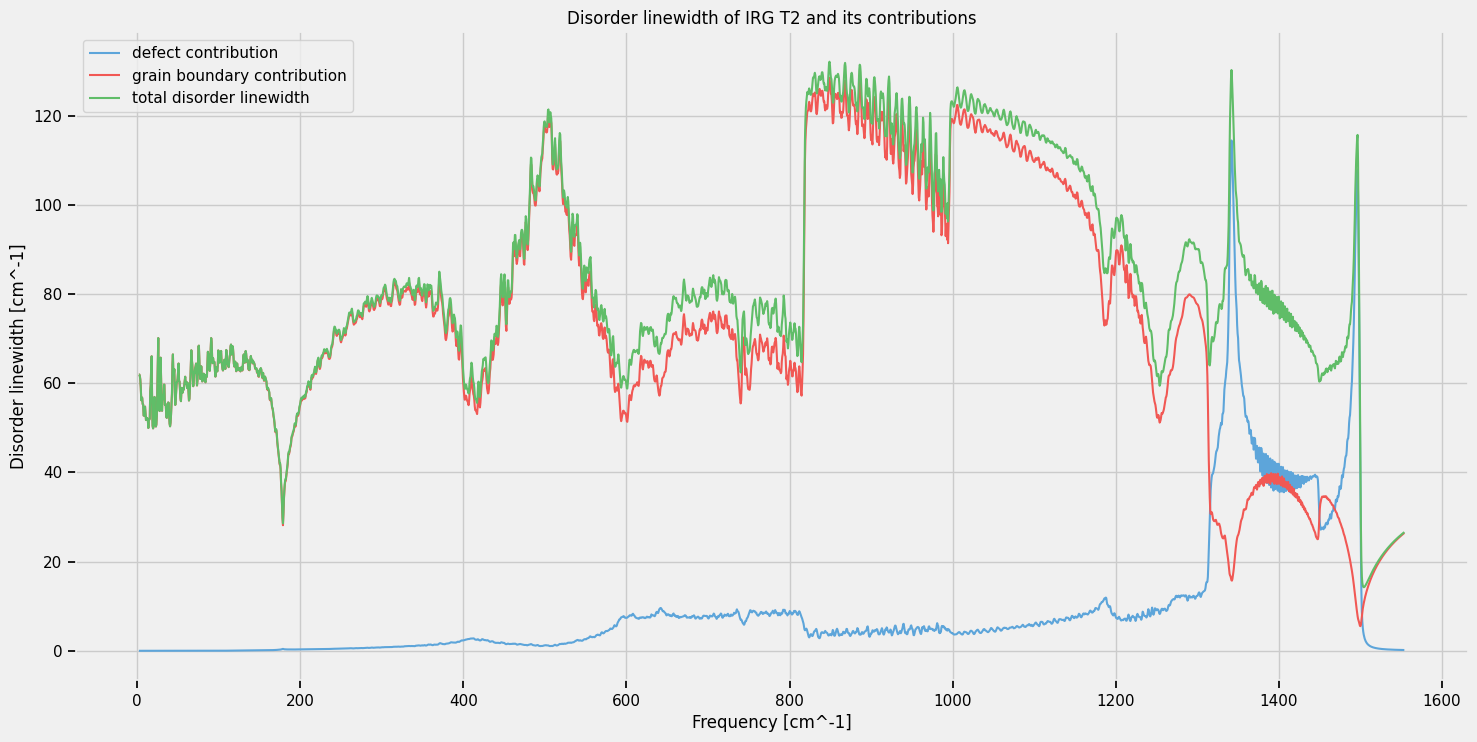

In [6]:
plt.figure(figsize=(16, 8))

plt.plot(interp_shifted_freq_crystal, defect_linewidth, color=Colors[3], label="defect contribution")
plt.plot(interp_shifted_freq_crystal, Casimir_model_linewidth, color=Colors[0], label="grain boundary contribution")
plt.plot(interp_shifted_freq_crystal, disorder_linewidth, color=Colors[2], label="total disorder linewidth")

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Disorder linewidth [cm^-1]")

plt.title("Disorder linewidth of IRG T2 and its contributions")

plt.legend(loc="upper left")

plt.show()

We can decompose the energy uncertainty of phonons in a perturbed crystal (disorder linewidth) in terms of contributions from defect and grain boundary scattering

In [7]:
def obtain_crystal_vdos():

    with h5py.File(f"{CRYSTAL_VEL_SAVE}.hdf5", "r") as f:
        freq_crystal = np.asarray(f["frequencies_bin"])  # [cm⁻¹]
        vdos_crystal = np.asarray(f["vdos_return"])      # [THz⁻¹ nm⁻³]

    return freq_crystal, vdos_crystal

freq_crystal, vdos_crystal = obtain_crystal_vdos()

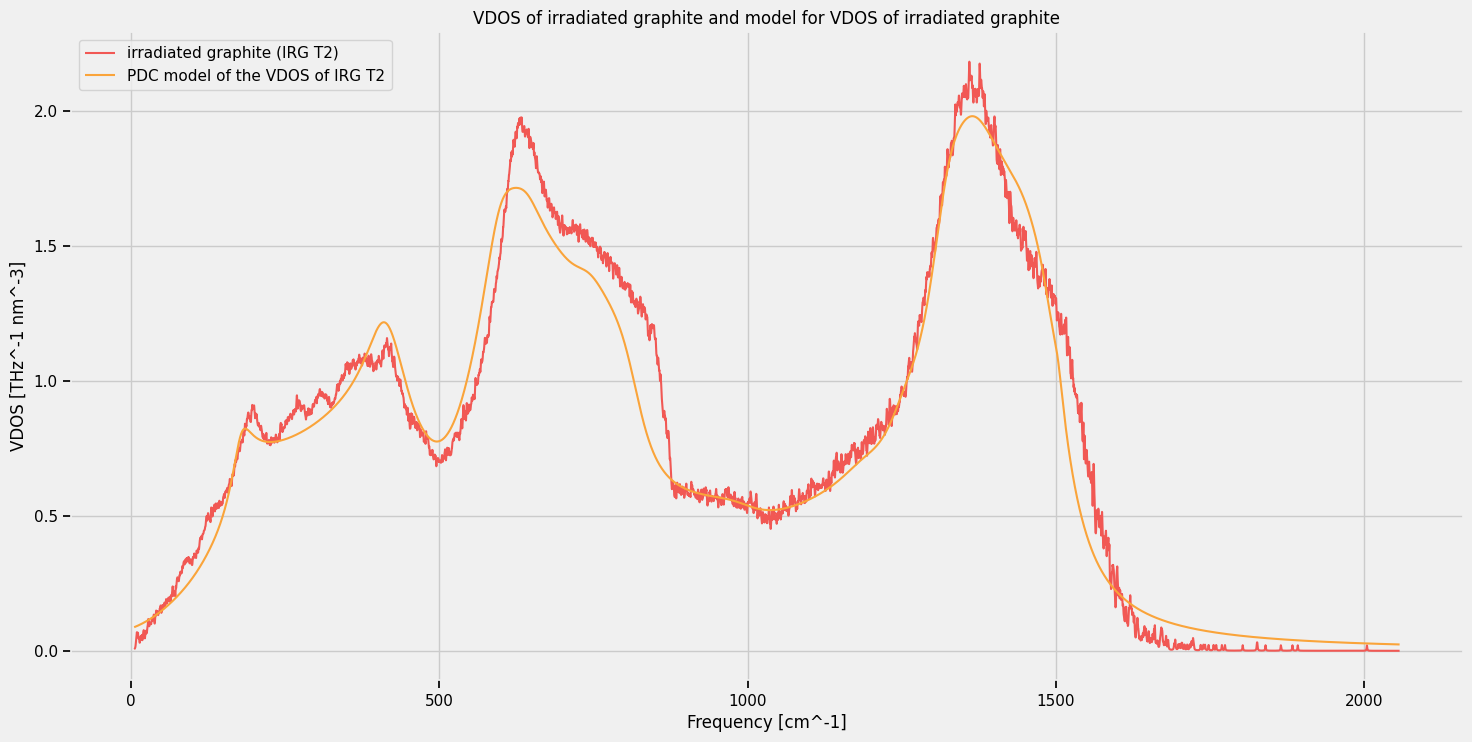

In [8]:
plt.figure(figsize=(16, 8))

plt.plot(freq_disordered, vdos_disordered, color=Colors[0], label='irradiated graphite (IRG T2)')
plt.plot(freq_disordered, vdos_PDC, color=Colors[1], label='PDC model of the VDOS of IRG T2')


plt.xlabel("Frequency [cm^-1]")
plt.ylabel("VDOS [THz^-1 nm^-3]")

plt.title("VDOS of irradiated graphite and model for VDOS of irradiated graphite")

plt.legend(loc="upper left")

plt.show()

We find that the PDC model of the VDOS approximates well the VDOS of IRG T2

## Propagation velocity and mean free path

<KeysViewHDF5 ['diffusivity', 'frequencies_plot']>


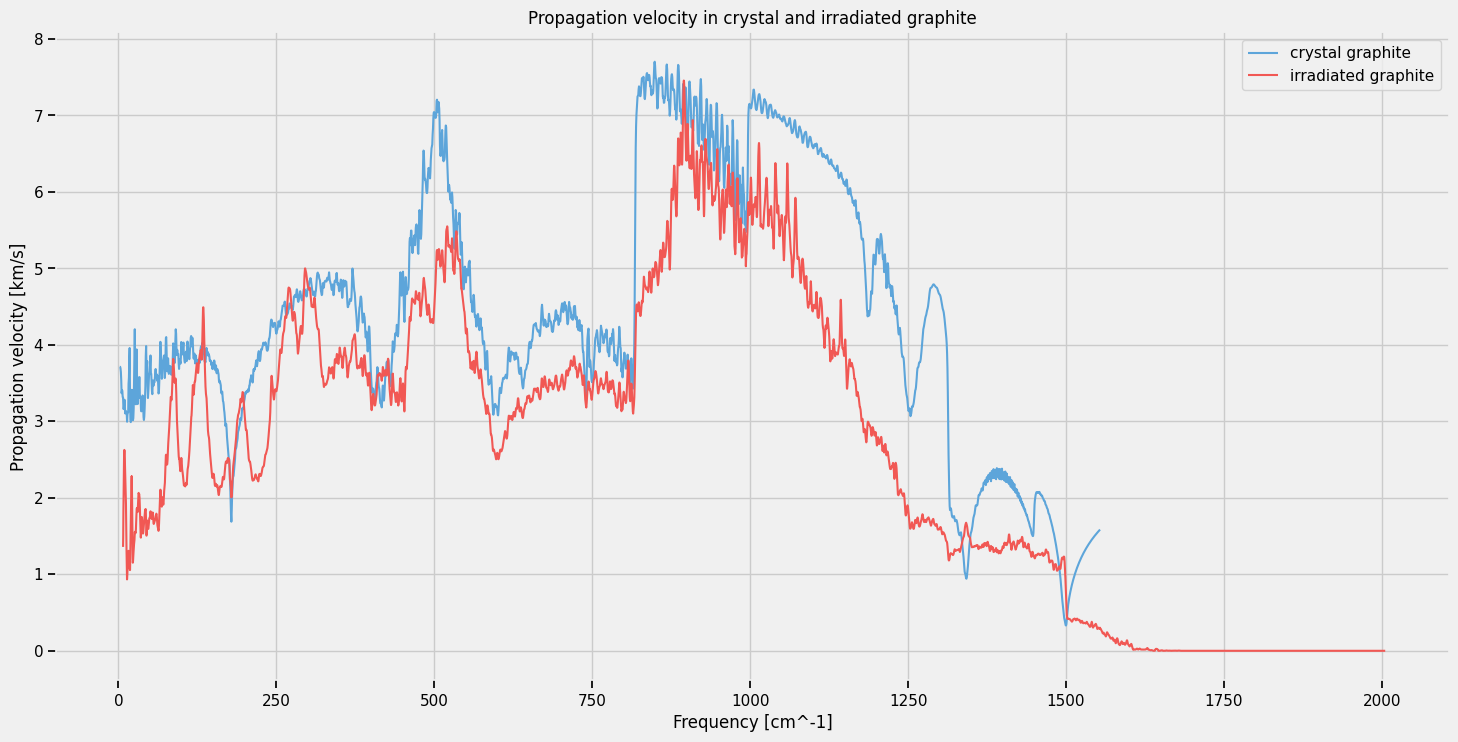

In [9]:
with h5py.File(DISORDERED_DIFFUSIVITY, "r") as f:
    print(f.keys())
    diffusivity_plot = np.asarray(f["diffusivity"])  # in m^2/s
    frequencies_plot_diff = np.asarray(f["frequencies_plot"])  # in cm^-1


lifetime = 1/disorder_linewidth * THzToCm * 1e-12  # in seconds
extrapolation_value = 1/24 * THzToCm * 1e-12
lifetime_function = interp1d(interp_shifted_freq_crystal, lifetime, bounds_error=False, fill_value=extrapolation_value)
lifetime_interpolated = lifetime_function(frequencies_plot_diff)

plt.figure(figsize=(16, 8))

plt.plot(interp_shifted_freq_crystal, interp_shifted_speed_crystal * 1e-3, color=Colors[3], label='crystal graphite')
plt.plot(frequencies_plot_diff, np.sqrt(diffusivity_plot/lifetime_interpolated) * 1e-3, color=Colors[0], label='irradiated graphite')


plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Propagation velocity [km/s]")

plt.title("Propagation velocity in crystal and irradiated graphite")

plt.legend(loc="upper right")

plt.show()

Propagation velocity follows similar trends to group velocity in crystal graphite, but has in general lower value.

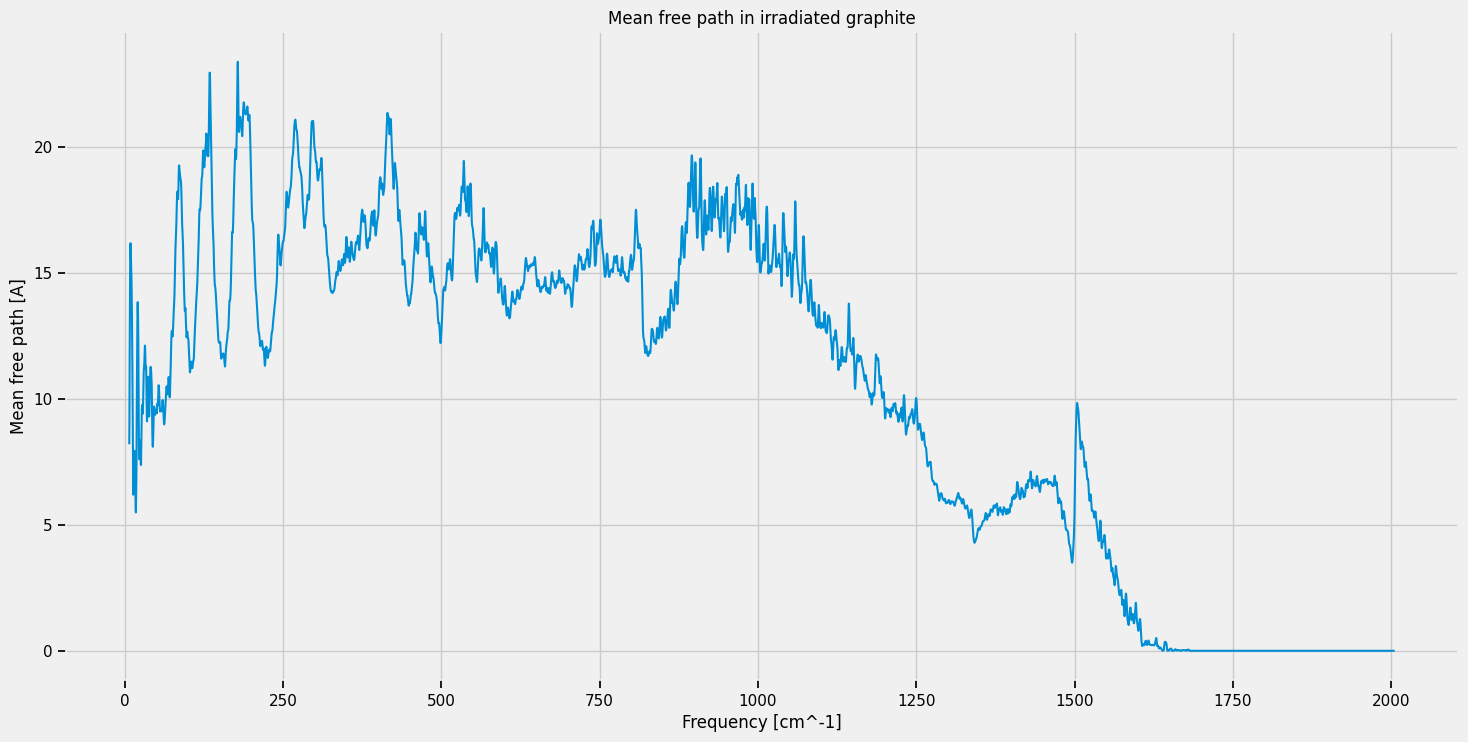

In [10]:
plt.figure(figsize=(16, 8))

plt.plot(frequencies_plot_diff, np.sqrt(diffusivity_plot*lifetime_interpolated) * 1e10)

plt.xlabel("Frequency [cm^-1]")
plt.ylabel("Mean free path [A]")

plt.title("Mean free path in irradiated graphite")

plt.show()

Mean free path is quite small, on the order of 20 A

The next notebook will explore how to fit the values of L and R